In [10]:
import numpy as np
import matplotlib.pyplot as plt
from sklearn.linear_model import LinearRegression
from sklearn.model_selection import train_test_split
from sklearn.metrics import r2_score, mean_absolute_error, root_mean_squared_error
np.random.seed(0)

In [11]:

#Make a toy dataset (y ≈ 3x + noise)N = 200
X = np.linspace(0, 10, N).reshape(-1, 1)            # feature matrix shape (N, 1)
noise = np.random.normal(0, 1.0, size=N)             # Gaussian noise
y = (3.0 * X.squeeze()) + 5 + noise                  # true slope=3, intercept=5

In [12]:
#Train–test split (hold‑out evaluation)
X_train, X_test, y_train, y_test = train_test_split(
    X, y, test_size=0.25, random_state=42
)
len(X_train), len(X_test)

(150, 50)

In [13]:
#Fit Linear Regression
lr = LinearRegression()          # ordinary least squares
lr.fit(X_train, y_train)

print("coef_ (slope):     ", lr.coef_[0])
print("intercept_:        ", lr.intercept_)

coef_ (slope):      3.0000714065442526
intercept_:         5.095545022522064


In [ ]:
#Predict and evaluate (R², MAE, RMSE)
y_pred = lr.predict(X_test)

r2   = r2_score(y_test, y_pred)
mae  = mean_absolute_error(y_test, y_pred)
rmse = root_mean_squared_error(y_test, y_pred)

print(f"R^2  = {r2:.3f}")
print(f"MAE  = {mae:.3f}")
print(f"RMSE = {rmse:.3f}")

#R² closer to 1 is better (fraction of variance explained).

#MAE/RMSE closer to 0 is better (typical error size; RMSE penalizes large errors more).

R^2  = 0.988
MAE  = 0.729
RMSE = 0.867


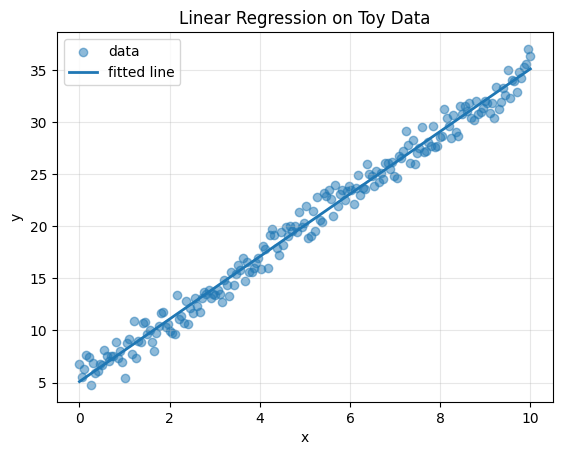

In [15]:
#Visualize: data + fitted line
# Sort for a nice line
order = np.argsort(X.squeeze())
X_line = X[order]
y_line = lr.predict(X_line)

plt.figure()
plt.scatter(X, y, alpha=0.5, label="data")
plt.plot(X_line, y_line, linewidth=2, label="fitted line")
plt.title("Linear Regression on Toy Data")
plt.xlabel("x"); plt.ylabel("y"); plt.legend(); plt.grid(True, alpha=0.3)
plt.show()

In [16]:
#Compare train vs test performance (sanity check)
y_pred_train = lr.predict(X_train)
r2_train = r2_score(y_train, y_pred_train)
r2_test  = r2_score(y_test,  y_pred)

print(f"R^2 train = {r2_train:.3f} | R^2 test = {r2_test:.3f}")

R^2 train = 0.986 | R^2 test = 0.988


In [17]:
#(Optional) Multiple features + PolynomialFeatures
#Add curvature with polynomial features:
from sklearn.preprocessing import PolynomialFeatures

poly = PolynomialFeatures(degree=2, include_bias=False)
X_poly = poly.fit_transform(X)              # columns: [x, x^2]
Xtr, Xte, ytr, yte = train_test_split(X_poly, y, test_size=0.25, random_state=42)

lr2 = LinearRegression().fit(Xtr, ytr)
print("coef_: ", lr2.coef_, " intercept_: ", lr2.intercept_)

yhat = lr2.predict(Xte)
print("R^2 poly (test): ", r2_score(yte, yhat))

coef_:  [2.98292072e+00 1.72639090e-03]  intercept_:  5.123084113082603
R^2 poly (test):  0.9883671974115357


In [18]:
         # feature matrix shape (N, 1)
noise1 = np.random.normal(0, 3.0, size=N)             # Gaussian noise
y1 = (3.0 * X.squeeze()) + 5 + noise                  # true slope=3, intercept=5

In [22]:
X1_train, X1_test, y1_train, y1_test = train_test_split(
    X, y1, test_size=0.25, random_state=42
)
len(X1_train), len(X1_test)

(150, 50)

In [24]:
lr1 = LinearRegression()          # ordinary least squares
lr1.fit(X1_train, y1_train)

print("coef_ (slope):     ", lr1.coef_[0])
print("intercept_:        ", lr1.intercept_)

coef_ (slope):      3.0000714065442526
intercept_:         5.095545022522064
